# Compare Estimators Across Configurations (J, N, P)

This notebook analyzes PyMC/ArviZ traces for different experimental settings:
- **J**: Choice set size (100, 200, 500)
- **N**: Population size (10k, 20k)
- **P**: Number of parameters (10, 20, 40)

**Analysis includes:**
- ArviZ summary with 94% HDI for all parameters
- Coverage: proportion of true parameters inside 94% HDI
- Posterior MSE: mean squared error of posterior samples
- Interval width and relative width
- RMSE and MAE of posterior means vs true values

In [1]:
import re
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import arviz as az
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

# Resolve paths relative to this repository (run the notebook from results/).
REPO_ROOT = Path.cwd().resolve().parent
sys.path.insert(0, str(REPO_ROOT / 'adaptive_sampler'))
from true_parameters import get_true_parameters

# Local adaptive-sampler output and the CSV used by compare_all_estimators.
RESULTS_DIR = REPO_ROOT / 'results'
M=0
TRACE_DIR = REPO_ROOT / 'adaptive_sampler' / 'output'

print(f'Results dir: {RESULTS_DIR}')
print(f'Trace dir: {TRACE_DIR}')
print(f'Trace dir exists: {TRACE_DIR.exists()}')

# display settings
pd.set_option('display.max_rows', 500)


Results dir: /Users/preto/Documents/EPFL/PhD/transp-or/TooManyAlternativesToHandle/results
Trace dir: /Users/preto/Documents/EPFL/PhD/transp-or/TooManyAlternativesToHandle/adaptive_sampler/output
Trace dir exists: True


## 1. Find and Parse Trace Files

In [2]:
def parse_filename_config(fname):
    """Extract J, N, P, M from filename like trace_J100_N20000_P20_prot2_mtm_steps5000.nc or trace_J200_N10000_P10_prot2_mtm_steps5000_m10.nc"""
    s = str(fname)
    
    # Extract J, N, P
    main_match = re.search(r'J(\d+)_N(\d+)_P(\d+)', s)
    if not main_match:
        return None
    
    J = int(main_match.group(1))
    N = int(main_match.group(2))
    P = int(main_match.group(3))
    
    # Extract M (default to 5 if not found)
    m_match = re.search(r'_m(\d+)', s)
    mtm = int(m_match.group(1)) if m_match else 5
    
    return {
        'J': J,
        'N': N,
        'P': P,
        'mtm': mtm,
        'file': fname
    }

# Find local traces and retain only the newest one for each (J, N, P).
# This lets the notebook work with a partial grid and prevents duplicate rows
# when a configuration has been rerun.
all_trace_files = sorted(TRACE_DIR.glob('trace_J*_N*_P*_*.nc')) if TRACE_DIR.exists() else []
latest_by_config = {}
for trace_path in all_trace_files:
    cfg = parse_filename_config(trace_path.name)
    if cfg is None:
        continue
    key = (cfg['J'], cfg['N'], cfg['P'])
    if key not in latest_by_config or trace_path.stat().st_mtime > latest_by_config[key].stat().st_mtime:
        latest_by_config[key] = trace_path
trace_files = [latest_by_config[key] for key in sorted(latest_by_config)]
print(f'\nFound {len(trace_files)} trace files:')
for f in trace_files[:15]:
    cfg = parse_filename_config(f.name)
    if cfg:
        print(f"  {f.name} → J={cfg['J']}, N={cfg['N']}, P={cfg['P']}, N={cfg['N']}")
    else:
        print(f"  {f.name} → Could not parse")

if len(trace_files) > 15:
    print(f'  ... and {len(trace_files) - 15} more files')


Found 1 trace files:
  trace_J100_N10000_P10_steps10000_SCALE_260909.nc → J=100, N=10000, P=10, N=10000


## 2. Load Traces and Compute ArviZ Summary

For each trace file, we:
1. Load with `az.from_netcdf()`
2. Get true parameters for that P value
3. Compute `az.summary()` with a 94% HDI (the 3%/97% interval used by the comparison notebook)

In [3]:
param_names={
    '10':['beta_rating',
 'beta_cost',
 'beta_log_dist',
 'beta_chinese',
 'beta_japanese',
 'beta_korean',
 'beta_indian',
 'beta_french',
 'beta_mexican',
 'beta_lebanese',
 ],
    '20':['beta_rating',
 'beta_cost',
 'beta_log_dist',
 'beta_chinese',
 'beta_japanese',
 'beta_korean',
 'beta_indian',
 'beta_french',
 'beta_mexican',
 'beta_lebanese',
 'beta_cost_x_logincome',
 'beta_logdist_x_age',
 'beta_rating_x_edu_sec',
 'beta_c_16',
 'beta_c_19',
 'beta_c_20',
 'beta_c_21',
 'beta_c_22',
 'beta_c_24',
 'beta_c_25',
 ],
    '40':['beta_rating',
 'beta_cost',
 'beta_log_dist',
 'beta_chinese',
 'beta_japanese',
 'beta_korean',
 'beta_indian',
 'beta_french',
 'beta_mexican',
 'beta_lebanese',
 'beta_cost_x_logincome',
 'beta_logdist_x_age',
 'beta_rating_x_edu_sec',
 'beta_c_16',
 'beta_c_19',
 'beta_c_20',
 'beta_c_21',
 'beta_c_22',
 'beta_c_24',
 'beta_c_25',
 'beta_c_26',
 'beta_c_27',
 'beta_c_29',
 'beta_c_30',
 'beta_c_32',
 'beta_c_33',
 'beta_c_34',
 'beta_c_35',
 'beta_d_36',
 'beta_d_37',
 'beta_d_38',
 'beta_d_39',
 'beta_d_41',
 'beta_d_42',
 'beta_d_43',
 'beta_d_44',
 'beta_d_45',
 'beta_d_46',
 'beta_d_49',
 'beta_d_50']
}

In [4]:
all_summaries = []
all_metrics = []
all_convergence = []

for nc_path in trace_files:
    cfg = parse_filename_config(nc_path.name)
    if cfg is None or cfg['P'] is None:
        print(f"Skipping {nc_path.name} (could not parse config)")
        continue
    
    J, N, P, mtm = cfg['J'], cfg['N'], cfg['P'], cfg['mtm']
    print(f"\nProcessing: J={J}, N={N}, P={P}, mtm={mtm} [{nc_path.name}]")
    
    try:
        # Load trace
        trace = az.from_netcdf(nc_path)
        
        # Get true parameters (using M parameter)
        true_params = get_true_parameters(P=P, M=M)
        # param_names = list(true_params.keys())
        
        # Use a 94% HDI so columns are hdi_3%/hdi_97%, matching
        # compare_all_estimators.ipynb and the other estimator summaries.
        summary = az.summary(trace, var_names=param_names[f'{P}'], hdi_prob=0.94, stat_focus="mean", round_to=None)
        
        # Add config columns to summary
        summary['J'] = J
        summary['N'] = N
        summary['P'] = P
        summary['mtm'] = mtm
        summary['M'] = M
        summary['file'] = nc_path.name
        summary['parameter'] = summary.index
        summary = summary.reset_index(drop=True)
        
        all_summaries.append(summary)
        
        # Compute per-parameter metrics
        for param in param_names[f'{P}']:
            if param not in trace.posterior.data_vars:
                continue
            if M == 0:
                true_val = true_params[param]
            if M == 1:
                true_val = 0.4*true_params[param]
            
            # Get posterior samples (flatten all chains and draws)
            samples = trace.posterior[param].values.flatten()
            
            # Posterior mean and HDI from summary
            post_mean = summary[summary['parameter'] == param]['mean'].values[0]
            hdi_low = summary[summary['parameter'] == param]['hdi_3%'].values[0]
            hdi_high = summary[summary['parameter'] == param]['hdi_97%'].values[0]
            
            # Convergence diagnostics from summary
            rhat = summary[summary['parameter'] == param]['r_hat'].values[0] if 'r_hat' in summary.columns else np.nan
            ess_bulk = summary[summary['parameter'] == param]['ess_bulk'].values[0] if 'ess_bulk' in summary.columns else np.nan
            ess_tail = summary[summary['parameter'] == param]['ess_tail'].values[0] if 'ess_tail' in summary.columns else np.nan
            
            # Check coverage
            in_hdi = (true_val >= hdi_low) and (true_val <= hdi_high)
            
            # Interval width
            interval_width = hdi_high - hdi_low
            rel_width = interval_width / abs(true_val) if abs(true_val) > 0.001 else np.nan
            
            # Posterior MSE
            posterior_mse = np.mean((samples - true_val)**2)
            
            # Point estimate errors
            abs_error = abs(post_mean - true_val)
            sq_error = (post_mean - true_val)**2
            
            all_metrics.append({
                'J': J, 'N': N, 'P': P, 'mtm': mtm,
                'file': nc_path.name,
                'parameter': param,
                'true_value': true_val,
                'posterior_mean': post_mean,
                'hdi_low': hdi_low,
                'hdi_high': hdi_high,
                'in_hdi': in_hdi,
                'interval_width': interval_width,
                'relative_width': rel_width,
                'posterior_mse': posterior_mse,
                'abs_error': abs_error,
                'sq_error': sq_error,
                'r_hat': rhat,
                'ess_bulk': ess_bulk,
                'ess_tail': ess_tail
            })
        
        # Compute file-level convergence summary
        rhat_values = summary['r_hat'].values if 'r_hat' in summary.columns else []
        ess_bulk_values = summary['ess_bulk'].values if 'ess_bulk' in summary.columns else []
        ess_tail_values = summary['ess_tail'].values if 'ess_tail' in summary.columns else []
        
        if len(rhat_values) > 0:
            # Check convergence: R-hat should be < 1.01 (stricter) or < 1.05 (more lenient)
            n_rhat_good = np.sum(rhat_values < 1.01)
            n_rhat_ok = np.sum(rhat_values < 1.05)
            n_rhat_bad = np.sum(rhat_values >= 1.05)
            max_rhat = np.max(rhat_values)
            
            # ESS should be > 400 (bulk) and > 400 (tail) for reliable inference
            n_ess_bulk_good = np.sum(ess_bulk_values > 400) if len(ess_bulk_values) > 0 else 0
            n_ess_tail_good = np.sum(ess_tail_values > 400) if len(ess_tail_values) > 0 else 0
            min_ess_bulk = np.min(ess_bulk_values) if len(ess_bulk_values) > 0 else np.nan
            min_ess_tail = np.min(ess_tail_values) if len(ess_tail_values) > 0 else np.nan
            
            all_convergence.append({
                'J': J, 'N': N, 'P': P, 'N': N,
                'file': nc_path.name,
                'n_parameters': len(param_names[f'{P}']),
                'n_rhat_good': n_rhat_good,
                'n_rhat_ok': n_rhat_ok,
                'n_rhat_bad': n_rhat_bad,
                'max_rhat': max_rhat,
                'n_ess_bulk_good': n_ess_bulk_good,
                'n_ess_tail_good': n_ess_tail_good,
                'min_ess_bulk': min_ess_bulk,
                'min_ess_tail': min_ess_tail,
                'converged': (n_rhat_bad == 0) and (min_ess_bulk > 40) and (min_ess_tail > 40)
            })
            
            conv_status = "✓ CONVERGED" if all_convergence[-1]['converged'] else "⚠ CONVERGENCE ISSUES"
            print(f"  {conv_status}: max R-hat={max_rhat:.4f}, min ESS_bulk={min_ess_bulk:.0f}, min ESS_tail={min_ess_tail:.0f}")

        print(f"  ✓ Processed {len(param_names[f'{P}'])} parameters")

    except Exception as e:
        print(f"  ✗ Error: {e}")
        continue

print(f"\n{'='*70}")
print(f"Total summaries collected: {len(all_summaries)}")
print(f"Total parameter-level metrics: {len(all_metrics)}")
print(f"Total convergence summaries: {len(all_convergence)}")
print(f"{'='*70}")


Processing: J=100, N=10000, P=10, mtm=5 [trace_J100_N10000_P10_steps10000_SCALE_260909.nc]
  ✓ CONVERGED: max R-hat=1.0100, min ESS_bulk=178, min ESS_tail=133
  ✓ Processed 10 parameters

Total summaries collected: 1
Total parameter-level metrics: 10
Total convergence summaries: 1


## 3. Create DataFrames with All Results

**DataFrame 1**: All ArviZ summaries (posterior mean, sd, HDI, ess, rhat, etc.)  
**DataFrame 2**: All quality indicators (coverage, RMSE, MAE, posterior MSE, interval widths)

In [5]:

df_summaries = pd.concat(all_summaries, ignore_index=True)
print(f"DataFrame 1: All ArviZ summaries")
print(f"Shape: {df_summaries.shape}")
print(f"Columns: {list(df_summaries.columns)}")
display(df_summaries.head(50))

DataFrame 1: All ArviZ summaries
Shape: (10, 16)
Columns: ['mean', 'sd', 'hdi_3%', 'hdi_97%', 'mcse_mean', 'mcse_sd', 'ess_bulk', 'ess_tail', 'r_hat', 'J', 'N', 'P', 'mtm', 'M', 'file', 'parameter']


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat,J,N,P,mtm,M,file,parameter
0,0.755,0.044,0.674,0.830,0.001,0.002,2500.0,3395.0,1.00,100,10000,10,5,0,trace_J100_N10000_P10_steps10000_SCALE_260909.nc,beta_rating
1,-0.405,0.012,-0.420,-0.391,0.000,0.002,2866.0,3110.0,1.00,100,10000,10,5,0,trace_J100_N10000_P10_steps10000_SCALE_260909.nc,beta_cost
2,-0.582,0.033,-0.639,-0.525,0.000,0.002,5400.0,4770.0,1.00,100,10000,10,5,0,trace_J100_N10000_P10_steps10000_SCALE_260909.nc,beta_log_dist
3,0.869,0.138,0.659,1.108,0.011,0.017,180.0,142.0,1.01,100,10000,10,5,0,trace_J100_N10000_P10_steps10000_SCALE_260909.nc,beta_chinese
4,1.330,0.132,1.118,1.551,0.011,0.017,178.0,138.0,1.01,100,10000,10,5,0,trace_J100_N10000_P10_steps10000_SCALE_260909.nc,beta_japanese
5,0.875,0.141,0.650,1.140,0.010,0.013,227.0,207.0,1.01,100,10000,10,5,0,trace_J100_N10000_P10_steps10000_SCALE_260909.nc,beta_korean
6,0.998,0.170,0.701,1.283,0.011,0.014,299.0,287.0,1.01,100,10000,10,5,0,trace_J100_N10000_P10_steps10000_SCALE_260909.nc,beta_indian
7,0.913,0.133,0.700,1.158,0.010,0.014,197.0,133.0,1.01,100,10000,10,5,0,trace_J100_N10000_P10_steps10000_SCALE_260909.nc,beta_french
8,1.364,0.132,1.142,1.593,0.010,0.015,194.0,149.0,1.01,100,10000,10,5,0,trace_J100_N10000_P10_steps10000_SCALE_260909.nc,beta_mexican
9,0.909,0.138,0.676,1.157,0.011,0.015,200.0,136.0,1.01,100,10000,10,5,0,trace_J100_N10000_P10_steps10000_SCALE_260909.nc,beta_lebanese


In [6]:

df_metrics = pd.DataFrame(all_metrics)
print(f"\nDataFrame 2: All quality indicators")
print(f"Shape: {df_metrics.shape}")
print(f"Columns: {list(df_metrics.columns)}")
display(df_metrics)


DataFrame 2: All quality indicators
Shape: (10, 19)
Columns: ['J', 'N', 'P', 'mtm', 'file', 'parameter', 'true_value', 'posterior_mean', 'hdi_low', 'hdi_high', 'in_hdi', 'interval_width', 'relative_width', 'posterior_mse', 'abs_error', 'sq_error', 'r_hat', 'ess_bulk', 'ess_tail']


,J,N,P,mtm,file,parameter,true_value,posterior_mean,hdi_low,hdi_high,in_hdi,interval_width,relative_width,posterior_mse,abs_error,sq_error,r_hat,ess_bulk,ess_tail
0,100,10000,10,5,trace_J100_N10000_P10_steps10000_SCALE_260909.nc,beta_rating,0.75,0.755,0.674,0.830,True,0.156,0.208000,0.001920,0.005,0.000025,1.00,2500.0,3395.0
1,100,10000,10,5,trace_J100_N10000_P10_steps10000_SCALE_260909.nc,beta_cost,-0.40,-0.405,-0.420,-0.391,True,0.029,0.072500,0.000165,0.005,0.000025,1.00,2866.0,3110.0
2,100,10000,10,5,trace_J100_N10000_P10_steps10000_SCALE_260909.nc,beta_log_dist,-0.60,-0.582,-0.639,-0.525,True,0.114,0.190000,0.001420,0.018,0.000324,1.00,5400.0,4770.0
3,100,10000,10,5,trace_J100_N10000_P10_steps10000_SCALE_260909.nc,beta_chinese,0.83,0.869,0.659,1.108,True,0.449,0.540964,0.020424,0.039,0.001521,1.01,180.0,142.0
4,100,10000,10,5,trace_J100_N10000_P10_steps10000_SCALE_260909.nc,beta_japanese,1.25,1.330,1.118,1.551,True,0.433,0.346400,0.023843,0.080,0.006400,1.01,178.0,138.0
5,100,10000,10,5,trace_J100_N10000_P10_steps10000_SCALE_260909.nc,beta_korean,0.75,0.875,0.650,1.140,True,0.490,0.653333,0.035741,0.125,0.015625,1.01,227.0,207.0
6,100,10000,10,5,trace_J100_N10000_P10_steps10000_SCALE_260909.nc,beta_indian,1.00,0.998,0.701,1.283,True,0.582,0.582000,0.028759,0.002,0.000004,1.01,299.0,287.0
7,100,10000,10,5,trace_J100_N10000_P10_steps10000_SCALE_260909.nc,beta_french,0.95,0.913,0.700,1.158,True,0.458,0.482105,0.019134,0.037,0.001369,1.01,197.0,133.0
8,100,10000,10,5,trace_J100_N10000_P10_steps10000_SCALE_260909.nc,beta_mexican,1.30,1.364,1.142,1.593,True,0.451,0.346923,0.021536,0.064,0.004096,1.01,194.0,149.0
9,100,10000,10,5,trace_J100_N10000_P10_steps10000_SCALE_260909.nc,beta_lebanese,0.90,0.909,0.676,1.157,True,0.481,0.534444,0.019248,0.009,0.000081,1.01,200.0,136.0


In [7]:
#J,N, P 500	20000	20
df_metrics[(df_metrics['J']==500) & (df_metrics['N']==20000) & (df_metrics['P']==40)].sort_values(by='r_hat', ascending=False)

,J,N,P,mtm,file,parameter,true_value,posterior_mean,hdi_low,hdi_high,in_hdi,interval_width,relative_width,posterior_mse,abs_error,sq_error,r_hat,ess_bulk,ess_tail


In [8]:
# sort by r_hat descending
df_metrics[df_metrics['parameter']=='beta_cost'].sort_values(by='r_hat', ascending=False)


,J,N,P,mtm,file,parameter,true_value,posterior_mean,hdi_low,hdi_high,in_hdi,interval_width,relative_width,posterior_mse,abs_error,sq_error,r_hat,ess_bulk,ess_tail
1,100,10000,10,5,trace_J100_N10000_P10_steps10000_SCALE_260909.nc,beta_cost,-0.4,-0.405,-0.42,-0.391,True,0.029,0.0725,0.000165,0.005,0.000025,1.0,2866.0,3110.0


In [9]:
df_metrics.to_csv(RESULTS_DIR / 'pymc_prior_gs_m0_parameter_metrics.csv', index=False)


<div class="alert alert-info">

**curse of dimensionality in MCMC ?**

when P increases, sampling quality degrades (higher r_hat, lower ess)
| Hypothesis                     | Supported? | Explanation                                 |
| ------------------------------ | ---------- | ------------------------------------------- |
| Global curse of dimensionality | ❌          | Most parameters mix fine; ESS high.         |
| Local correlation problem      | ✅          | Only cost-related parameters are stuck.     |
| Model mis-identification       | ❌          | Posteriors still centered near true values. |




</div>

In [10]:
beta_cost_df= df_metrics[df_metrics['parameter']=='beta_cost'] 
#re order per P
beta_cost_df = beta_cost_df.sort_values(by=['P'])
display(beta_cost_df)


,J,N,P,mtm,file,parameter,true_value,posterior_mean,hdi_low,hdi_high,in_hdi,interval_width,relative_width,posterior_mse,abs_error,sq_error,r_hat,ess_bulk,ess_tail
1,100,10000,10,5,trace_J100_N10000_P10_steps10000_SCALE_260909.nc,beta_cost,-0.4,-0.405,-0.42,-0.391,True,0.029,0.0725,0.000165,0.005,0.000025,1.0,2866.0,3110.0


In [11]:
# DataFrame 3: Convergence diagnostics by file
if all_convergence:
    df_convergence = pd.DataFrame(all_convergence)
    print(f"\nDataFrame 3: Convergence diagnostics")
    print(f"Shape: {df_convergence.shape}")
    print(f"Columns: {list(df_convergence.columns)}")
    print("\n" + "="*80)
    print("CONVERGENCE SUMMARY")
    print("="*80)
    display(df_convergence.sort_values(['P', 'J', 'N']))
    
    # Quick summary
    n_converged = df_convergence['converged'].sum()
    n_total = len(df_convergence)
    print(f"\n✓ Converged: {n_converged}/{n_total} ({n_converged/n_total*100:.1f}%)")
    
    if n_converged < n_total:
        print(f"\n⚠ Files with convergence issues:")
        issues = df_convergence[~df_convergence['converged']]
        for _, row in issues.iterrows():
            print(f"  - {row['file']}: max R-hat={row['max_rhat']:.4f}, min ESS_bulk={row['min_ess_bulk']:.0f}")
else:
    print("No convergence diagnostics available")
    df_convergence = pd.DataFrame()


DataFrame 3: Convergence diagnostics
Shape: (1, 14)
Columns: ['J', 'N', 'P', 'file', 'n_parameters', 'n_rhat_good', 'n_rhat_ok', 'n_rhat_bad', 'max_rhat', 'n_ess_bulk_good', 'n_ess_tail_good', 'min_ess_bulk', 'min_ess_tail', 'converged']

CONVERGENCE SUMMARY


,J,N,P,file,n_parameters,n_rhat_good,n_rhat_ok,n_rhat_bad,max_rhat,n_ess_bulk_good,n_ess_tail_good,min_ess_bulk,min_ess_tail,converged
0,100,10000,10,trace_J100_N10000_P10_steps10000_SCALE_260909.nc,10,3,10,0,1.01,3,3,178.0,133.0,True



✓ Converged: 1/1 (100.0%)


## 4. Aggregate Indicators by Configuration (J, N, P, M)

Compute aggregated metrics for each configuration:
- **Coverage**: proportion of parameters where true value is in 95% HDI
- **Mean interval width**: average HDI width
- **Mean relative width**: average HDI width / |true value|
- **RMSE**: root mean squared error of posterior means
- **MAE**: mean absolute error of posterior means
- **Mean posterior MSE**: average posterior MSE across parameters

In [12]:
if not df_metrics.empty:
    agg = df_metrics.groupby(['J', 'N', 'P', 'mtm']).agg({
        'in_hdi': 'mean',
        'interval_width': 'mean',
        'relative_width': lambda x: np.nanmean(x),
        'posterior_mse': 'mean',
        'abs_error': 'mean',
        'sq_error': lambda x: np.sqrt(np.mean(x)),  # RMSE
        'r_hat': ['mean', 'max'],
        'ess_bulk': ['mean', 'min'],
        'ess_tail': ['mean', 'min'],
        'parameter': 'count'
    })
    
    # Flatten multi-level columns
    agg.columns = ['_'.join(col).strip('_') if col[1] else col[0] for col in agg.columns.values]
    agg = agg.reset_index()
    
    # Rename columns based on actual flattened names
    agg = agg.rename(columns={
        'in_hdi_mean': 'coverage',
        'interval_width_mean': 'mean_interval_width',
        'relative_width_<lambda>': 'mean_relative_width',
        'posterior_mse_mean': 'mean_posterior_mse',
        'abs_error_mean': 'mae',
        'sq_error_<lambda>': 'rmse',
        'r_hat_mean': 'mean_rhat',
        'r_hat_max': 'max_rhat',
        'ess_bulk_mean': 'mean_ess_bulk',
        'ess_bulk_min': 'min_ess_bulk',
        'ess_tail_mean': 'mean_ess_tail',
        'ess_tail_min': 'min_ess_tail',
        'parameter_count': 'n_parameters'
    })
    
    agg['coverage_pct'] = agg['coverage'] * 100
    
    # Add convergence flag: converged if max_rhat < 1.05 and min ESS > 400
    agg['converged'] = (agg['max_rhat'] < 1.05) & (agg['min_ess_bulk'] > 400) & (agg['min_ess_tail'] > 400)
    
    print("\n" + "="*80)
    print("AGGREGATED INDICATORS BY CONFIGURATION")
    print("="*80)
    display(agg.sort_values(['P', 'J', 'N']))
    
    # Save to CSV
    out_csv = RESULTS_DIR / 'aggregated_indicators_by_config.csv'
    agg.to_csv(out_csv, index=False)
    print(f"\n✓ Saved aggregated indicators to: {out_csv}")
    
    # Convergence summary
    n_configs = len(agg)
    n_converged = agg['converged'].sum()
    print(f"\n📊 Convergence: {n_converged}/{n_configs} configurations converged ({n_converged/n_configs*100:.1f}%)")
    
    if n_converged < n_configs:
        print("\n⚠ Configurations with convergence issues:")
        issues = agg[~agg['converged']][['J', 'N', 'P', 'max_rhat', 'min_ess_bulk', 'min_ess_tail']]
        display(issues)
else:
    print("No metrics to aggregate")
    agg = pd.DataFrame()


AGGREGATED INDICATORS BY CONFIGURATION


,J,N,P,mtm,coverage,mean_interval_width,mean_relative_width,mean_posterior_mse,mae,rmse,mean_rhat,max_rhat,mean_ess_bulk,min_ess_bulk,mean_ess_tail,min_ess_tail,n_parameters,coverage_pct,converged
0,100,10000,10,5,1.0,0.3643,0.395667,0.017219,0.0384,0.054286,1.007,1.01,1224.1,178.0,1246.7,133.0,10,100.0,False



✓ Saved aggregated indicators to: /Users/preto/Documents/EPFL/PhD/transp-or/TooManyAlternativesToHandle/results/aggregated_indicators_by_config.csv

📊 Convergence: 0/1 configurations converged (0.0%)

⚠ Configurations with convergence issues:


,J,N,P,max_rhat,min_ess_bulk,min_ess_tail
0,100,10000,10,1.01,178.0,133.0


## 5. Visualizations

Compare performance across configurations

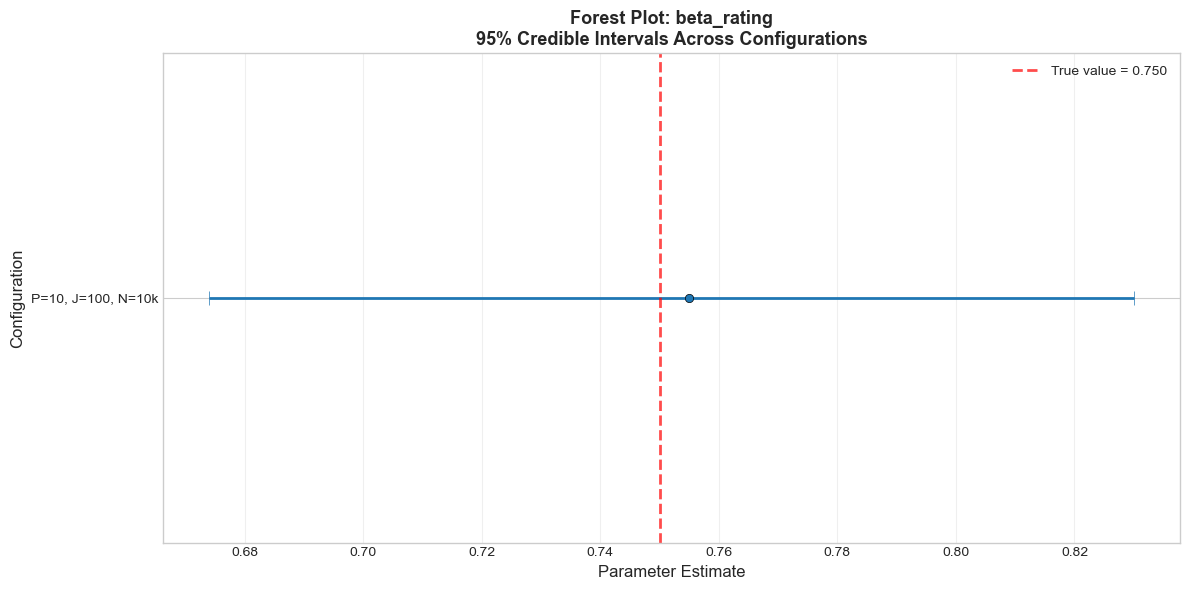

In [13]:
# Forest Plot: Parameter estimates with credible intervals across configurations
# Select parameter to visualize
parameter_to_plot = 'beta_rating'  # Change this to any parameter you want to visualize

param_data = df_metrics[df_metrics['parameter'] == parameter_to_plot].copy()
    
# Create configuration labels
param_data['config'] = param_data.apply(
    lambda row: f"P={row['P']}, J={row['J']}, N={row['N']//1000}k", axis=1
)

# Sort by P, J, N for better visualization
param_data = param_data.sort_values(['P', 'J', 'N'])

# Get true value for reference line
true_value = param_data['true_value'].iloc[0]

# Create figure
fig, ax = plt.subplots(figsize=(12, max(6, len(param_data) * 0.4)))

# Define colors for P values
colors = {10: 'C0', 20: 'C1', 40: 'C2'}
param_data['color'] = param_data['P'].map(colors)

# Plot error bars (credible intervals) - plot each point individually to handle colors
y_positions = range(len(param_data))
for idx, (_, row) in enumerate(param_data.iterrows()):
    ax.errorbar(
        row['posterior_mean'], 
        idx,
        xerr=[[row['posterior_mean'] - row['hdi_low']], 
              [row['hdi_high'] - row['posterior_mean']]],
        fmt='o',
        markersize=6,
        capsize=5,
        capthick=2,
        linewidth=2,
        ecolor=row['color'],
        markerfacecolor=row['color'],
        markeredgecolor='black',
        markeredgewidth=0.5
    )

# Add true value reference line
ax.axvline(true_value, color='red', linestyle='--', linewidth=2, 
           label=f'True value = {true_value:.3f}', alpha=0.7)

# Customize plot
ax.set_yticks(y_positions)
ax.set_yticklabels(param_data['config'])
ax.set_xlabel('Parameter Estimate', fontsize=12)
ax.set_ylabel('Configuration', fontsize=12)
ax.set_title(f'Forest Plot: {parameter_to_plot}\n95% Credible Intervals Across Configurations', 
             fontsize=13, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(alpha=0.3, axis='x')

# Invert y-axis so first config is at top
ax.invert_yaxis()

plt.tight_layout()
plt.savefig(f'/Users/preto/Documents/EPFL/PhD/projects/Bayesian/bayesian-choice-modeling-w-alt-sampling/results/results_pymc/forest_plot_{parameter_to_plot}.pdf')
plt.show()

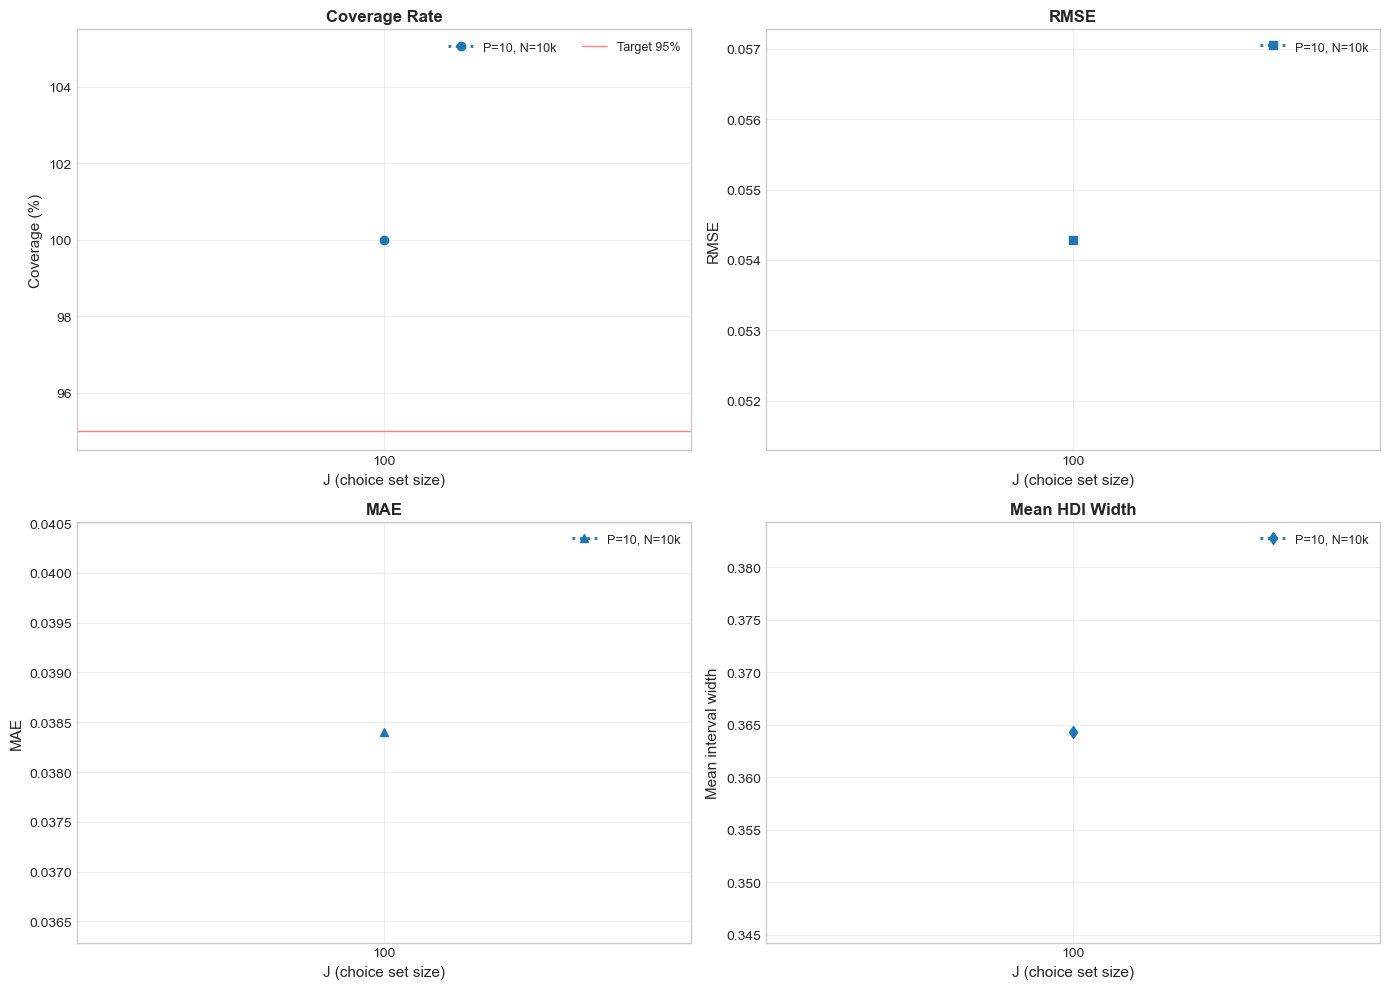

In [14]:
if not agg.empty:
    # Define colors for P values and line styles for N values
    colors = {10: 'C0', 20: 'C1', 40: 'C2'}
    linestyles = {10000: ':', 20000: '--', 50000: '-'}
    n_labels = {10000: '10k', 20000: '20k', 50000: '50k'}
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 1. Coverage by J, with P as curves and N as line styles
    ax = axes[0, 0]
    for p_val in sorted(agg['P'].unique()):
        for n_val in sorted(agg['N'].unique()):
            data = agg[(agg['P'] == p_val) & (agg['N'] == n_val)]
            ax.plot(data['J'], data['coverage_pct'], 
                   marker='o', color=colors[p_val], linestyle=linestyles[n_val],
                   label=f'P={p_val}, N={n_labels[n_val]}', linewidth=2)
    ax.axhline(95, color='red', linestyle='-', linewidth=1, label='Target 95%', alpha=0.5)
    ax.set_xlabel('J (choice set size)', fontsize=11)
    ax.set_ylabel('Coverage (%)', fontsize=11)
    ax.set_title('Coverage Rate', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9, ncol=2)
    ax.grid(alpha=0.3)
    ax.set_xticks(sorted(agg['J'].unique()))
    
    # 2. RMSE by J, with P as curves and N as line styles
    ax = axes[0, 1]
    for p_val in sorted(agg['P'].unique()):
        for n_val in sorted(agg['N'].unique()):
            data = agg[(agg['P'] == p_val) & (agg['N'] == n_val)]
            ax.plot(data['J'], data['rmse'], 
                   marker='s', color=colors[p_val], linestyle=linestyles[n_val],
                   label=f'P={p_val}, N={n_labels[n_val]}', linewidth=2)
    ax.set_xlabel('J (choice set size)', fontsize=11)
    ax.set_ylabel('RMSE', fontsize=11)
    ax.set_title('RMSE', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9, ncol=2)
    ax.grid(alpha=0.3)
    ax.set_xticks(sorted(agg['J'].unique()))
    
    # 3. MAE by J, with P as curves and N as line styles
    ax = axes[1, 0]
    for p_val in sorted(agg['P'].unique()):
        for n_val in sorted(agg['N'].unique()):
            data = agg[(agg['P'] == p_val) & (agg['N'] == n_val)]
            ax.plot(data['J'], data['mae'], 
                   marker='^', color=colors[p_val], linestyle=linestyles[n_val],
                   label=f'P={p_val}, N={n_labels[n_val]}', linewidth=2)
    ax.set_xlabel('J (choice set size)', fontsize=11)
    ax.set_ylabel('MAE', fontsize=11)
    ax.set_title('MAE', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9, ncol=2)
    ax.grid(alpha=0.3)
    ax.set_xticks(sorted(agg['J'].unique()))
    
    # 4. Mean interval width by J, with P as curves and N as line styles
    ax = axes[1, 1]
    for p_val in sorted(agg['P'].unique()):
        for n_val in sorted(agg['N'].unique()):
            data = agg[(agg['P'] == p_val) & (agg['N'] == n_val)]
            ax.plot(data['J'], data['mean_interval_width'], 
                   marker='d', color=colors[p_val], linestyle=linestyles[n_val],
                   label=f'P={p_val}, N={n_labels[n_val]}', linewidth=2)
    ax.set_xlabel('J (choice set size)', fontsize=11)
    ax.set_ylabel('Mean interval width', fontsize=11)
    ax.set_title('Mean HDI Width', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9, ncol=2)
    ax.grid(alpha=0.3)
    ax.set_xticks(sorted(agg['J'].unique()))
    
    plt.tight_layout()
    plt.show()
else:
    print("No aggregated data to plot")

NameError: name 'sns' is not defined

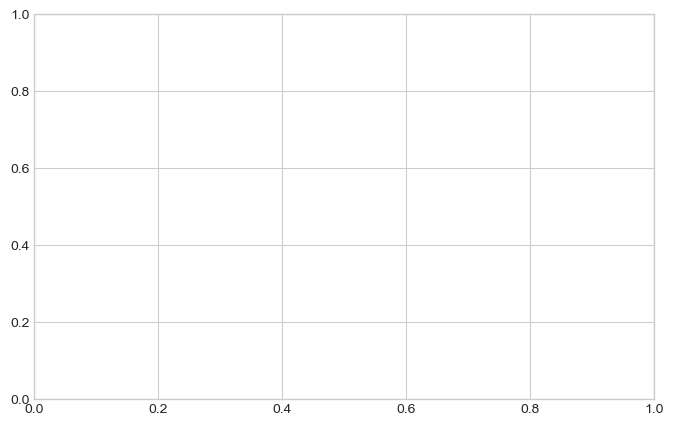

In [15]:
# Heatmap: Coverage by P and J (for largest N)
if not agg.empty:
    max_n = 10000
    sub = agg[agg['N'] == max_n].pivot(index='P', columns='J', values='coverage_pct')
    
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.heatmap(sub, annot=True, fmt='.1f', cmap='RdYlGn', vmin=80, vmax=100, 
                cbar_kws={'label': 'Coverage (%)'}, ax=ax)
    ax.set_title(f'Coverage (%) by P and J (N={max_n})', fontsize=13, fontweight='bold')
    ax.set_xlabel('J (choice set size)', fontsize=11)
    ax.set_ylabel('P (number of parameters)', fontsize=11)
    plt.tight_layout()
    plt.show()

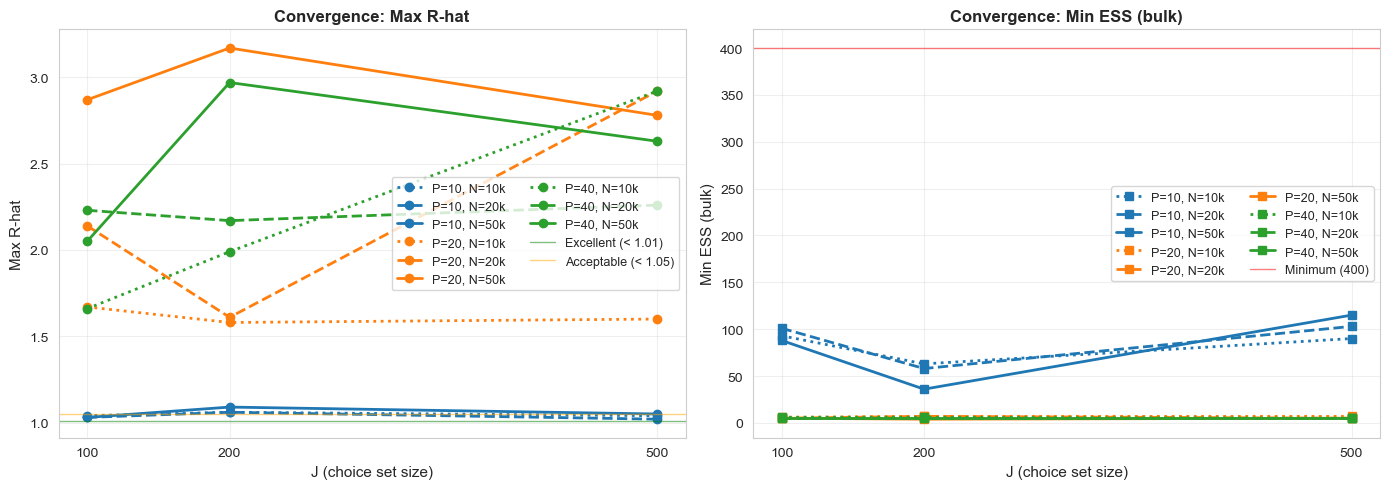

In [ ]:
# Convergence diagnostics visualization
if not agg.empty and 'max_rhat' in agg.columns:
    # Define colors for P values and line styles for N values
    colors = {10: 'C0', 20: 'C1', 40: 'C2'}
    linestyles = {10000: ':', 20000: '--', 50000: '-'}
    n_labels = {10000: '10k', 20000: '20k', 50000: '50k'}
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # 1. Max R-hat by J, with P as curves and N as line styles
    ax = axes[0]
    for p_val in sorted(agg['P'].unique()):
        for n_val in sorted(agg['N'].unique()):
            data = agg[(agg['P'] == p_val) & (agg['N'] == n_val)]
            ax.plot(data['J'], data['max_rhat'], 
                   marker='o', color=colors[p_val], linestyle=linestyles[n_val],
                   label=f'P={p_val}, N={n_labels[n_val]}', linewidth=2)
    ax.axhline(1.01, color='green', linestyle='-', linewidth=1, label='Excellent (< 1.01)', alpha=0.5)
    ax.axhline(1.05, color='orange', linestyle='-', linewidth=1, label='Acceptable (< 1.05)', alpha=0.5)
    ax.set_xlabel('J (choice set size)', fontsize=11)
    ax.set_ylabel('Max R-hat', fontsize=11)
    ax.set_title('Convergence: Max R-hat', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9, ncol=2)
    ax.grid(alpha=0.3)
    ax.set_xticks(sorted(agg['J'].unique()))
    
    # 2. Min ESS (bulk) by J, with P as curves and N as line styles
    ax = axes[1]
    for p_val in sorted(agg['P'].unique()):
        for n_val in sorted(agg['N'].unique()):
            data = agg[(agg['P'] == p_val) & (agg['N'] == n_val)]
            ax.plot(data['J'], data['min_ess_bulk'], 
                   marker='s', color=colors[p_val], linestyle=linestyles[n_val],
                   label=f'P={p_val}, N={n_labels[n_val]}', linewidth=2)
    ax.axhline(400, color='red', linestyle='-', linewidth=1, label='Minimum (400)', alpha=0.5)
    ax.set_xlabel('J (choice set size)', fontsize=11)
    ax.set_ylabel('Min ESS (bulk)', fontsize=11)
    ax.set_title('Convergence: Min ESS (bulk)', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9, ncol=2)
    ax.grid(alpha=0.3)
    ax.set_xticks(sorted(agg['J'].unique()))
    
    plt.tight_layout()
    plt.show()

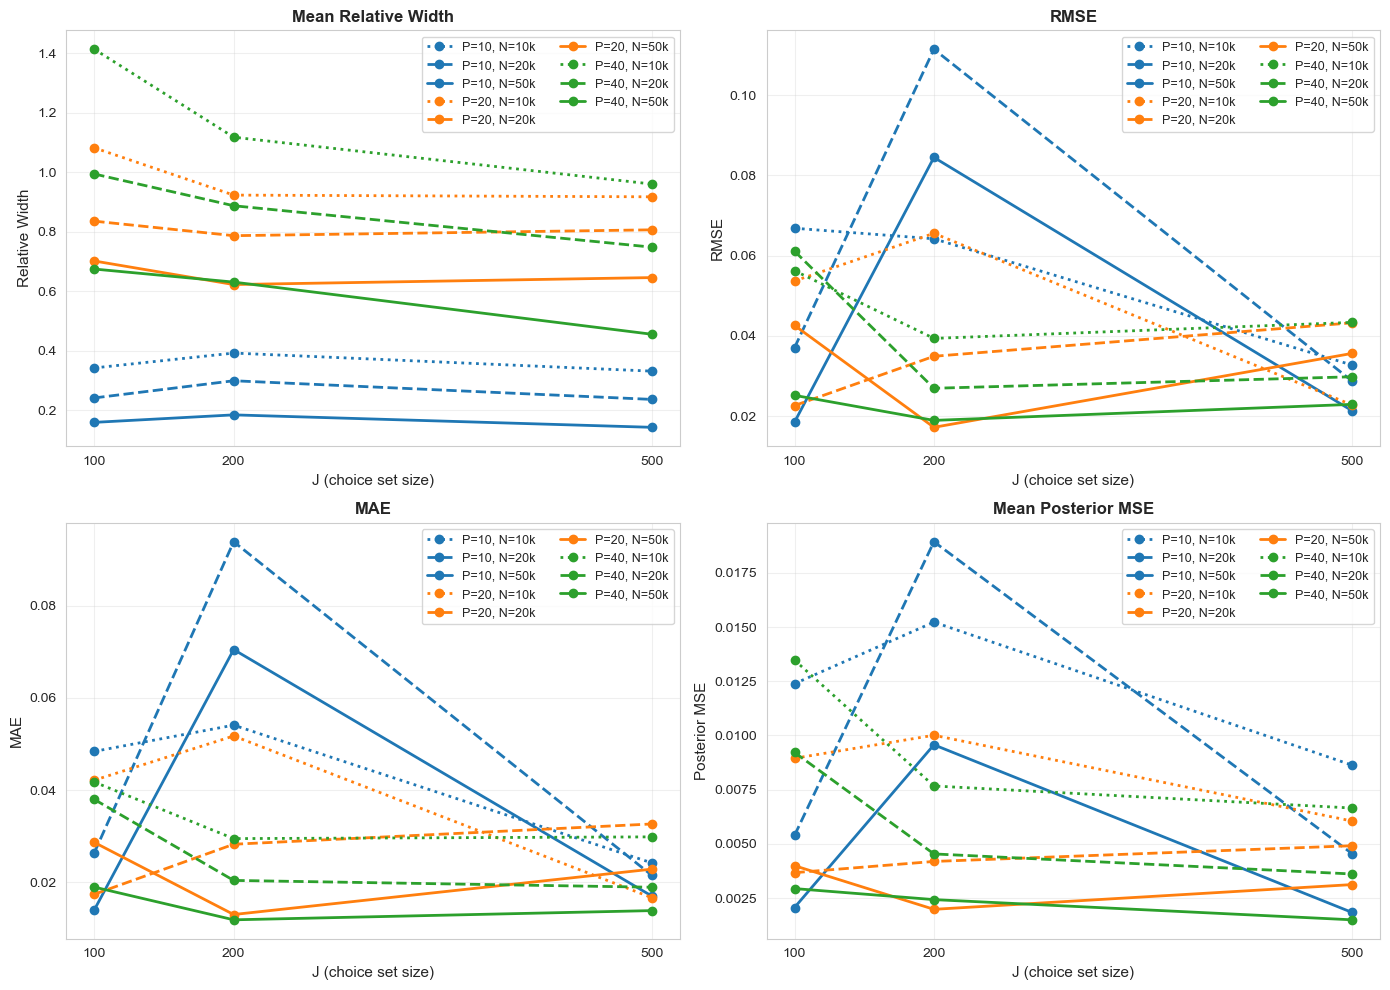

In [ ]:
# Additional plots: Metrics by J (X-axis), with P as curves and N as line styles
if not agg.empty:
    # Define colors for P values and line styles for N values
    colors = {10: 'C0', 20: 'C1', 40: 'C2'}
    linestyles = {10000: ':', 20000: '--', 50000: '-'}
    n_labels = {10000: '10k', 20000: '20k', 50000: '50k'}
    
    # Metrics to plot
    metrics = [
        ('mean_relative_width', 'Mean Relative Width', 'Relative Width'),
        ('rmse', 'RMSE', 'RMSE'),
        ('mae', 'MAE', 'MAE'),
        ('mean_posterior_mse', 'Mean Posterior MSE', 'Posterior MSE')
    ]
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    for idx, (metric_col, metric_title, ylabel) in enumerate(metrics):
        ax = axes[idx]
        
        # Plot each combination of P and N
        for p_val in sorted(agg['P'].unique()):
            for n_val in sorted(agg['N'].unique()):
                data = agg[(agg['P'] == p_val) & (agg['N'] == n_val)]
                ax.plot(data['J'], data[metric_col], 
                       marker='o', color=colors[p_val], linestyle=linestyles[n_val],
                       label=f'P={p_val}, N={n_labels[n_val]}', linewidth=2, markersize=6)
        
        ax.set_xlabel('J (choice set size)', fontsize=11)
        ax.set_ylabel(ylabel, fontsize=11)
        ax.set_title(metric_title, fontsize=12, fontweight='bold')
        ax.legend(loc='best', fontsize=9, ncol=2)
        ax.grid(alpha=0.3)
        ax.set_xticks(sorted(agg['J'].unique()))
    
    plt.tight_layout()
    plt.show()
else:
    print("No aggregated data to plot")



## 6. Save Results to CSV

Save both dataframes for further analysis

In [ ]:
# # Save DataFrame 1: All ArviZ summaries
# if not df_summaries.empty:
#     out_summaries = RESULTS_DIR / 'all_arviz_summaries.csv'
#     df_summaries.to_csv(out_summaries, index=False)
#     print(f"✓ Saved all ArviZ summaries to: {out_summaries}")
#     print(f"  Shape: {df_summaries.shape}")

# # Save DataFrame 2: All quality indicators
# if not df_metrics.empty:
#     out_metrics = RESULTS_DIR / 'all_quality_indicators.csv'
#     df_metrics.to_csv(out_metrics, index=False)
#     print(f"✓ Saved all quality indicators to: {out_metrics}")
#     print(f"  Shape: {df_metrics.shape}")

# # Save DataFrame 3: Convergence diagnostics
# if not df_convergence.empty:
#     out_convergence = RESULTS_DIR / 'convergence_diagnostics.csv'
#     df_convergence.to_csv(out_convergence, index=False)
#     print(f"✓ Saved convergence diagnostics to: {out_convergence}")
#     print(f"  Shape: {df_convergence.shape}")

# print("\n" + "="*80)
# print("ANALYSIS COMPLETE!")
# print("="*80)

✓ Saved all ArviZ summaries to: ../../results/all_arviz_summaries.csv
  Shape: (390, 14)
✓ Saved all quality indicators to: ../../results/all_quality_indicators.csv
  Shape: (390, 18)
✓ Saved convergence diagnostics to: ../../results/convergence_diagnostics.csv
  Shape: (18, 14)

ANALYSIS COMPLETE!
